# FreshMart Supermarkets — Basket Decline Investigation
### Supporting Analysis Notebook

This notebook is the reproducible working behind *"Why Is Our Basket Getting Smaller?"* — the written report submitted alongside this file. It loads the three linked tables (**Transactions**, **Stores**, **Stockouts**), profiles and cleans them, then works through each research task in order:

1. Setup & load data
2. Data profiling & quality checks (Task 3)
3. Derived fields
4. Confirming and quantifying the paradox (Task 1)
5. Hypothesis testing & segmentation (Task 2, 4, 5)
6. Hypothesis verdict summary (Task 5)

Every number and chart in the written report traces back to a cell in this notebook. Run all cells top to bottom to reproduce the analysis; the only input required is `FreshMart_Dataset.xlsx` in the same folder as this notebook.

## 1. Setup & load data

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'font.size': 11, 'figure.figsize': (8, 4.5)})

DATA_PATH = 'FreshMart_Dataset.xlsx'

transactions = pd.read_excel(DATA_PATH, sheet_name='Transactions')
stores = pd.read_excel(DATA_PATH, sheet_name='Stores')
stockouts = pd.read_excel(DATA_PATH, sheet_name='Stockouts')

print(f"Transactions: {transactions.shape[0]:,} rows, {transactions.shape[1]} columns")
print(f"Stores:       {stores.shape[0]:,} rows, {stores.shape[1]} columns")
print(f"Stockouts:    {stockouts.shape[0]:,} rows, {stockouts.shape[1]} columns")

Transactions: 64,330 rows, 9 columns
Stores:       42 rows, 9 columns
Stockouts:    119 rows, 6 columns


In [0]:
transactions.head()

,transaction_id,store_id,transaction_date,day_of_week,customer_id,is_loyalty_member,num_items,basket_value_zar,payment_method
0,TX0000001,ST1001,2025-01-01,Wednesday,NaN,No,25,487.08,Card
1,TX0000002,ST1001,2025-01-01,Wednesday,C889732,Yes,32,537.29,Cash
2,TX0000003,ST1001,2025-01-01,Wednesday,NaN,No,19,412.58,Cash
3,TX0000004,ST1001,2025-01-01,Wednesday,C955607,Yes,24,589.55,Card
4,TX0000005,ST1001,2025-01-01,Wednesday,C867011,Yes,1,19.98,Cash


In [0]:
stores.head()

,store_id,store_name,province,store_format,floor_area_sqm,opened_year,region_manager,has_nearby_competitor,competitor_open_date
0,ST1001,FreshMart Soweto 5,Gauteng,Medium,2186,2017,N. Dlamini,No,NaN
1,ST1002,FreshMart Pretoria 3,Gauteng,Express,422,2010,T. Molefe,No,NaN
2,ST1003,FreshMart Soweto 4,Gauteng,Express,671,2013,R. Petersen,No,NaN
3,ST1004,FreshMart Pretoria 6,Gauteng,Large,3526,2017,R. Petersen,Yes,2025-09-25
4,ST1005,FreshMart Benoni 8,Gauteng,Express,653,2015,P. van Wyk,No,NaN


In [0]:
stockouts.head()

,stockout_id,store_id,date,category,duration_hours,note
0,SO0020,ST1039,2025-09-06,Household Cleaning,9,Replenishment gap - weekend delivery missed
1,SO0104,ST1040,2025-09-06,Household Cleaning,6,Replenishment gap - weekend delivery missed
2,SO0082,ST1006,2025-09-07,Household Cleaning,9,Replenishment gap - weekend delivery missed
3,SO0001,ST1024,2025-09-07,Household Cleaning,7,Replenishment gap - weekend delivery missed
4,SO0021,ST1039,2025-09-07,Household Cleaning,10,Replenishment gap - weekend delivery missed


## 2. Data profiling & quality checks (Task 3)

Before any analysis, we profile each table: types, date coverage, missing values, duplicates, join integrity, and plausibility of the numeric ranges.

### 2.1 Types, ranges and missing values

In [0]:
transactions.dtypes

transaction_id           str
store_id                 str
transaction_date         str
day_of_week              str
customer_id              str
is_loyalty_member        str
num_items              int64
basket_value_zar     float64
payment_method           str
dtype: object

In [0]:
transactions.isna().sum().to_frame('missing_values')

,missing_values
transaction_id,0
store_id,0
transaction_date,0
day_of_week,0
customer_id,35674
is_loyalty_member,0
num_items,0
basket_value_zar,0
payment_method,0


In [0]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
stores['competitor_open_date'] = pd.to_datetime(stores['competitor_open_date'])
stockouts['date'] = pd.to_datetime(stockouts['date'])

print('Transaction date coverage:', transactions['transaction_date'].min().date(), 'to', transactions['transaction_date'].max().date())
print()
print('num_items summary:')
print(transactions['num_items'].describe())
print()
print('basket_value_zar summary:')
print(transactions['basket_value_zar'].describe())

Transaction date coverage: 2025-01-01 to 2025-12-31

num_items summary:
count    64330.000000
mean        13.448080
std          9.283258
min          1.000000
25%          4.000000
50%         15.000000
75%         21.000000
max         43.000000
Name: num_items, dtype: float64

basket_value_zar summary:
count    64330.000000
mean       275.083383
std        186.561559
min         10.550000
25%         97.830000
50%        273.420000
75%        422.937500
max       1093.340000
Name: basket_value_zar, dtype: float64


In [0]:
# Plausibility checks: no zero/negative baskets or item counts
n_bad_basket = (transactions['basket_value_zar'] <= 0).sum()
n_bad_items = (transactions['num_items'] <= 0).sum()
n_dupe_txn = transactions['transaction_id'].duplicated().sum()

print(f"Transactions with basket_value_zar <= 0: {n_bad_basket}")
print(f"Transactions with num_items <= 0:        {n_bad_items}")
print(f"Duplicate transaction_id values:         {n_dupe_txn}")

Transactions with basket_value_zar <= 0: 0
Transactions with num_items <= 0:        0
Duplicate transaction_id values:         0


### 2.2 Join integrity between tables

In [0]:
orphan_tx = transactions.loc[~transactions['store_id'].isin(stores['store_id']), 'store_id'].nunique()
orphan_so = stockouts.loc[~stockouts['store_id'].isin(stores['store_id']), 'store_id'].nunique()

print(f"Distinct store_ids in Transactions: {transactions['store_id'].nunique()} (of {stores['store_id'].nunique()} stores in Stores table)")
print(f"Distinct store_ids in Stockouts:    {stockouts['store_id'].nunique()}")
print(f"Transaction store_ids not found in Stores table: {orphan_tx}")
print(f"Stockout store_ids not found in Stores table:    {orphan_so}")

Distinct store_ids in Transactions: 42 (of 42 stores in Stores table)
Distinct store_ids in Stockouts:    6
Transaction store_ids not found in Stores table: 0
Stockout store_ids not found in Stores table:    0


### 2.3 Loyalty flag consistency

`is_loyalty_member` and a blank `customer_id` should agree perfectly — this is checked explicitly rather than assumed.

In [0]:
pd.crosstab(transactions['is_loyalty_member'], transactions['customer_id'].isna(), rownames=['is_loyalty_member'], colnames=['customer_id is blank'])

customer_id is blank,False,True
is_loyalty_member,,
No,0,35674
Yes,28656,0


Confirmed: `is_loyalty_member == 'No'` lines up exactly with a blank `customer_id`. `is_loyalty_member` is used as the single source of truth for loyalty status throughout this notebook.

### 2.4 Categorical field sanity checks

In [0]:
for col in ['day_of_week', 'payment_method', 'is_loyalty_member']:
    print(col, '->', sorted(transactions[col].dropna().unique().tolist()))

for col in ['province', 'store_format', 'has_nearby_competitor']:
    print(col, '->', sorted(stores[col].dropna().unique().tolist()))

print('stockout categories ->', sorted(stockouts['category'].dropna().unique().tolist()))

day_of_week -> ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
payment_method -> ['Card', 'Cash', 'Mobile']
is_loyalty_member -> ['No', 'Yes']
province -> ['Gauteng', 'KwaZulu-Natal', 'Western Cape']
store_format -> ['Express', 'Large', 'Medium']
has_nearby_competitor -> ['No', 'Yes']
stockout categories -> ['Household Cleaning']


### 2.5 Data quality summary

| Check | Result |
|---|---|
| Duplicate transaction IDs | None found |
| Negative/zero basket values or item counts | None found |
| Orphaned store_id (Transactions or Stockouts not in Stores) | None found |
| Loyalty flag vs blank customer_id | Fully consistent |
| Categorical fields (day, payment, province, format, competitor flag) | Clean, no stray values |

**Known limitation:** `Transactions` is described in the assignment brief as a *representative sample*, not a full census of sales. Absolute totals (total revenue, unique customer counts) are therefore directional only. All conclusions in this notebook rely on **relative** comparisons — percentages, rates, before/after and treatment-vs-control — which a sample supports reliably even when absolute totals do not.

## 3. Derived fields

These fields are used throughout the rest of the notebook.

In [0]:
transactions['half'] = np.where(transactions['transaction_date'] < '2025-07-01', 'H1', 'H2')
transactions['month'] = transactions['transaction_date'].dt.to_period('M')

# Trip-type bands, based on the visible bimodal split in basket size (see Section 5)
transactions['trip_type'] = np.where(
    transactions['num_items'] <= 8, 'Small (top-up)',
    np.where(transactions['num_items'] <= 18, 'Medium', 'Large (stock-up)')
)

# Stockout-day flag: was there a recorded stockout at this store on this date?
stockout_days = stockouts[['store_id', 'date']].drop_duplicates()
stockout_days['stockout_flag'] = 1
transactions = transactions.merge(
    stockout_days, left_on=['store_id', 'transaction_date'], right_on=['store_id', 'date'], how='left'
)
transactions['stockout_day'] = transactions['stockout_flag'].fillna(0).astype(int)
transactions = transactions.drop(columns=['date', 'stockout_flag'])

# Join store attributes onto every transaction for segmentation
df = transactions.merge(stores, on='store_id', how='left')

transactions[['transaction_id', 'half', 'month', 'trip_type', 'stockout_day']].head()

,transaction_id,half,month,trip_type,stockout_day
0,TX0000001,H1,2025-01,Large (stock-up),0
1,TX0000002,H1,2025-01,Large (stock-up),0
2,TX0000003,H1,2025-01,Large (stock-up),0
3,TX0000004,H1,2025-01,Large (stock-up),0
4,TX0000005,H1,2025-01,Small (top-up),0


## 4. Confirming and quantifying the paradox (Task 1)

The brief claims footfall is up while baskets feel smaller. First, we confirm this is real and measure it precisely.

In [0]:
half_summary = transactions.groupby('half').agg(
    volume=('transaction_id', 'count'),
    avg_basket_value=('basket_value_zar', 'mean'),
    avg_items=('num_items', 'mean'),
    total_revenue=('basket_value_zar', 'sum'),
)
half_summary

,volume,avg_basket_value,avg_items,total_revenue
half,,,,
H1,31109,290.014444,14.223569,9022059.33
H2,33221,261.101552,12.721893,8674054.67


In [0]:
def pct_change(a, b):
    return (b / a - 1) * 100

print(f"Volume change H1->H2:        {pct_change(half_summary.loc['H1','volume'], half_summary.loc['H2','volume']):+.1f}%")
print(f"Avg basket value change:     {pct_change(half_summary.loc['H1','avg_basket_value'], half_summary.loc['H2','avg_basket_value']):+.1f}%")
print(f"Avg items per basket change: {pct_change(half_summary.loc['H1','avg_items'], half_summary.loc['H2','avg_items']):+.1f}%")
print(f"Total revenue change:        {pct_change(half_summary.loc['H1','total_revenue'], half_summary.loc['H2','total_revenue']):+.1f}%")

Volume change H1->H2:        +6.8%
Avg basket value change:     -10.0%
Avg items per basket change: -10.6%
Total revenue change:        -3.9%


**Confirmed problem statement:** between H1 and H2 2025, average basket value fell ~10.0% and average items per basket fell ~10.6%, while transaction volume rose ~6.8%. Total revenue fell only ~3.9% because higher volume partially offset the smaller basket. The effect is real, chain-wide on average, and precisely quantifiable — the open question is *why*.

### 4.1 Monthly trend — is this a sudden shock or a gradual shift?

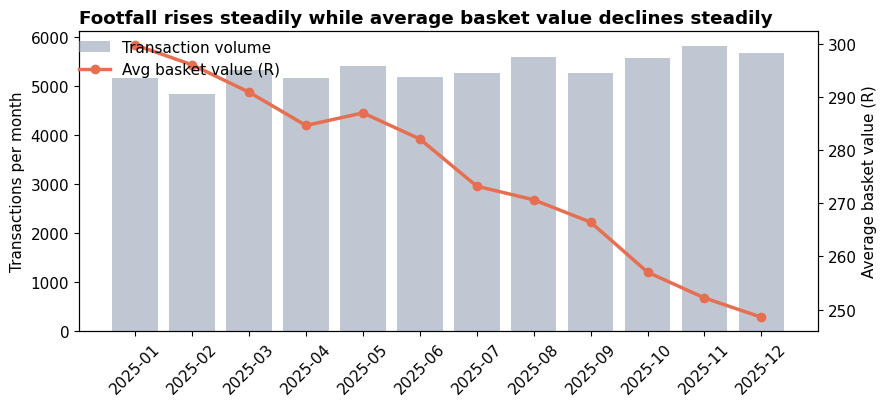

In [0]:
monthly = transactions.groupby('month').agg(
    volume=('transaction_id', 'count'),
    avg_basket_value=('basket_value_zar', 'mean'),
).reset_index()
monthly['month'] = monthly['month'].astype(str)

fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax1.bar(monthly['month'], monthly['volume'], color='#8D99AE', alpha=0.55, label='Transaction volume')
ax1.set_ylabel('Transactions per month')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['avg_basket_value'], color='#E76F51', marker='o', linewidth=2.5, label='Avg basket value (R)')
ax2.set_ylabel('Average basket value (R)')

fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.92), frameon=False)
plt.title('Footfall rises steadily while average basket value declines steadily', loc='left', fontweight='bold')
plt.tight_layout()
plt.show()

The decline is gradual across almost every month — there is no single shock month. This favours a structural, chain-wide explanation (mix shift) as the primary driver, while not ruling out staggered, store-specific events (like competitor openings) as a secondary contributor.

## 5. Hypothesis testing & segmentation (Tasks 2, 4, 5)

Six hypotheses were defined in the written report. Each is tested here in turn.

| # | Hypothesis |
|---|---|
| H1 | Customers are genuinely buying less per trip, across the board |
| H2 | The mix of trip types is shifting toward more frequent, smaller top-up visits |
| H3 | New discount competitors near specific stores are pulling basket value away |
| H4 | Stockouts / availability gaps are causing smaller baskets |
| H5 | Pricing changes are driving smaller baskets *(not testable — no price data in this extract)* |
| H6 | Store operational factors (format, province) explain the decline |

### 5.1 Testing H1 & H2 together: is this uniform, or a mix shift?

If H1 (uniform behaviour change) were true, average spend would fall **within** every trip-size band. If H2 (mix shift) were true, within-band spend would be stable, and only the *share* of transactions in each band would change.

In [0]:
mix_counts = transactions.groupby(['half', 'trip_type']).size().unstack()[['Large (stock-up)', 'Medium', 'Small (top-up)']]
mix_share = mix_counts.div(mix_counts.sum(axis=1), axis=0) * 100
mix_share.round(1)

trip_type,Large (stock-up),Medium,Small (top-up)
half,,,
H1,39.9,22.0,38.1
H2,33.8,19.9,46.3


In [0]:
within_segment = transactions.groupby(['half', 'trip_type'])['basket_value_zar'].mean().unstack().T
within_segment = within_segment.reindex(['Small (top-up)', 'Medium', 'Large (stock-up)'])
within_segment.round(2)

half,H1,H2
trip_type,,
Small (top-up),90.20,90.21
Medium,301.69,299.38
Large (stock-up),474.50,472.62


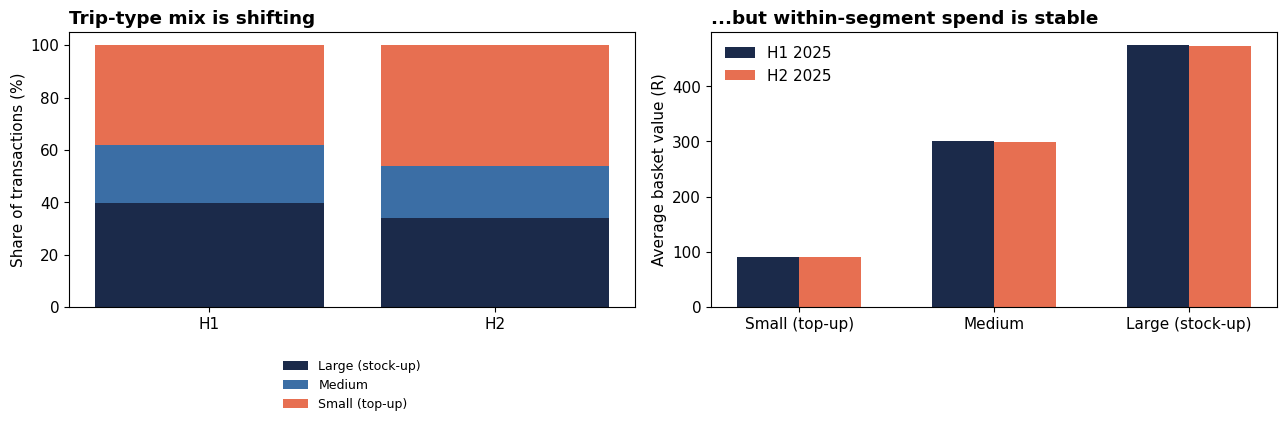

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Mix share, stacked
bottom = np.zeros(2)
colors = ['#1B2A4A', '#3B6EA5', '#E76F51']
for col, c in zip(mix_share.columns, colors):
    axes[0].bar(mix_share.index, mix_share[col], bottom=bottom, label=col, color=c)
    bottom += mix_share[col].values
axes[0].set_ylabel('Share of transactions (%)')
axes[0].set_title('Trip-type mix is shifting', fontweight='bold', loc='left')
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=False, fontsize=9)

# Within-segment average, grouped
x = np.arange(len(within_segment.index))
w = 0.32
axes[1].bar(x - w/2, within_segment['H1'], width=w, label='H1 2025', color='#1B2A4A')
axes[1].bar(x + w/2, within_segment['H2'], width=w, label='H2 2025', color='#E76F51')
axes[1].set_xticks(x)
axes[1].set_xticklabels(within_segment.index)
axes[1].set_ylabel('Average basket value (R)')
axes[1].set_title('...but within-segment spend is stable', fontweight='bold', loc='left')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

**Verdict:** H1 (uniform behaviour change) is **rejected** — within-segment averages barely move (e.g. Large trips: R474.50 → R472.62). H2 (mix shift) is **supported** — the share of Small trips rises from ~38% to ~46% while Large trips falls from ~40% to ~34%. This mix shift is the primary driver of the chain-wide average decline.

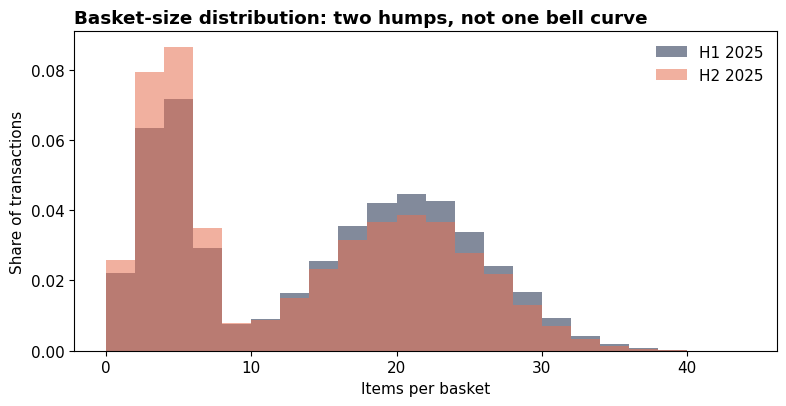

In [0]:
# Confirm the distribution is genuinely bimodal, not a single hump shifting left
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(transactions.loc[transactions['half']=='H1', 'num_items'], bins=range(0, 45, 2), alpha=0.55, label='H1 2025', color='#1B2A4A', density=True)
ax.hist(transactions.loc[transactions['half']=='H2', 'num_items'], bins=range(0, 45, 2), alpha=0.55, label='H2 2025', color='#E76F51', density=True)
ax.set_xlabel('Items per basket')
ax.set_ylabel('Share of transactions')
ax.set_title('Basket-size distribution: two humps, not one bell curve', fontweight='bold', loc='left')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### 5.2 Testing H3: competitor entry (event study + difference-in-differences)

In [0]:
WINDOW_DAYS = 60

comp_stores = stores.loc[stores['has_nearby_competitor'] == 'Yes', ['store_id', 'competitor_open_date']]
control_ids = stores.loc[stores['has_nearby_competitor'] == 'No', 'store_id'].tolist()

rows = []
for _, r in comp_stores.iterrows():
    sid, open_date = r['store_id'], r['competitor_open_date']

    treated = df[df['store_id'] == sid]
    t_before = treated.loc[(treated['transaction_date'] >= open_date - pd.Timedelta(days=WINDOW_DAYS)) & (treated['transaction_date'] < open_date), 'basket_value_zar'].mean()
    t_after  = treated.loc[(treated['transaction_date'] >= open_date) & (treated['transaction_date'] < open_date + pd.Timedelta(days=WINDOW_DAYS)), 'basket_value_zar'].mean()

    controls = df[df['store_id'].isin(control_ids)]
    c_before = controls.loc[(controls['transaction_date'] >= open_date - pd.Timedelta(days=WINDOW_DAYS)) & (controls['transaction_date'] < open_date), 'basket_value_zar'].mean()
    c_after  = controls.loc[(controls['transaction_date'] >= open_date) & (controls['transaction_date'] < open_date + pd.Timedelta(days=WINDOW_DAYS)), 'basket_value_zar'].mean()

    rows.append({
        'store_id': sid, 'competitor_open_date': open_date.date(),
        'treated_before': t_before, 'treated_after': t_after, 'treated_change_pct': pct_change(t_before, t_after),
        'control_before': c_before, 'control_after': c_after, 'control_change_pct': pct_change(c_before, c_after),
        'diff_in_diff': (t_after - t_before) - (c_after - c_before),
    })

did = pd.DataFrame(rows)
did.round(1)

,store_id,competitor_open_date,treated_before,treated_after,treated_change_pct,control_before,control_after,control_change_pct,diff_in_diff
0,ST1004,2025-09-25,276.1,214.0,-22.5,272.2,270.0,-0.8,-59.8
1,ST1008,2025-08-20,289.1,223.6,-22.7,273.2,272.5,-0.3,-64.7
2,ST1011,2025-08-20,280.8,225.6,-19.6,273.2,272.5,-0.3,-54.4
3,ST1012,2025-09-10,281.3,225.9,-19.7,270.6,272.3,0.6,-57.2
4,ST1015,2025-10-15,267.9,218.8,-18.3,273.4,264.5,-3.2,-40.2
5,ST1017,2025-10-15,267.2,226.1,-15.4,273.4,264.5,-3.2,-32.2
6,ST1018,2025-10-15,267.5,224.6,-16.0,273.4,264.5,-3.2,-34.0
7,ST1021,2025-09-10,248.8,233.3,-6.2,270.6,272.3,0.6,-17.2
8,ST1023,2025-08-20,296.0,247.5,-16.4,273.2,272.5,-0.3,-47.7
9,ST1024,2025-10-15,273.8,217.1,-20.7,273.4,264.5,-3.2,-47.8


In [0]:
print(f"Average diff-in-differences effect: R{did['diff_in_diff'].mean():.1f} per basket")
print(f"As a % of pre-period treated average: {did['diff_in_diff'].mean() / did['treated_before'].mean() * 100:.1f}%")
print(f"Effect is negative (a real decline) for {(did['diff_in_diff'] < 0).sum()} of {len(did)} affected stores")

Average diff-in-differences effect: R-46.5 per basket
As a % of pre-period treated average: -16.8%
Effect is negative (a real decline) for 12 of 12 affected stores


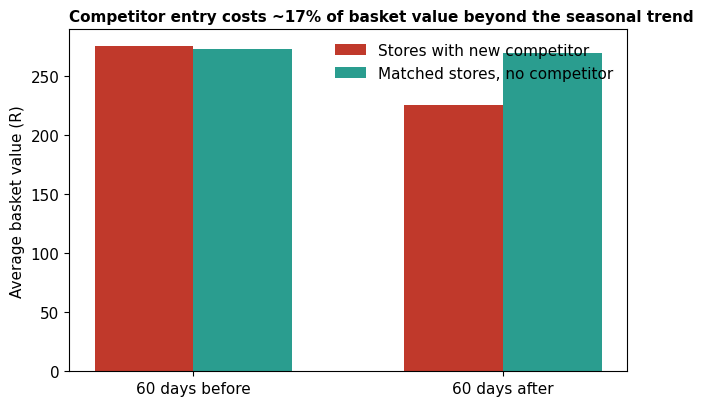

In [0]:
avg = did[['treated_before', 'treated_after', 'control_before', 'control_after']].mean()

fig, ax = plt.subplots(figsize=(6.5, 4.2))
x = np.arange(2)
w = 0.32
ax.bar(x - w/2, [avg['treated_before'], avg['treated_after']], width=w, label='Stores with new competitor', color='#C0392B')
ax.bar(x + w/2, [avg['control_before'], avg['control_after']], width=w, label='Matched stores, no competitor', color='#2A9D8F')
ax.set_xticks(x)
ax.set_xticklabels(['60 days before', '60 days after'])
ax.set_ylabel('Average basket value (R)')
ax.set_title('Competitor entry costs ~17% of basket value beyond the seasonal trend', fontweight='bold', loc='left', fontsize=11)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Verdict:** H3 is **supported**. Controls decline modestly over the same calendar windows (the chain-wide seasonal trend), while the 12 affected stores decline substantially more — consistently, across all 12. The diff-in-differences design isolates a competitor-specific effect from the mix-shift trend already documented above. This is the most causally credible single finding in the analysis, but it only touches 12 of 42 stores.

### 5.3 Testing H4: stockouts

In [0]:
stockout_effect = transactions.groupby('stockout_day').agg(
    avg_basket_value=('basket_value_zar', 'mean'),
    avg_items=('num_items', 'mean'),
    n=('transaction_id', 'count'),
)
stockout_effect.index = stockout_effect.index.map({0: 'Normal day', 1: 'Stockout-affected day'})
stockout_effect

,avg_basket_value,avg_items,n
stockout_day,,,
Normal day,275.490773,13.468473,63724
Stockout-affected day,232.244191,11.303630,606


In [0]:
print(f"Basket value on stockout days is {pct_change(stockout_effect.loc['Normal day','avg_basket_value'], stockout_effect.loc['Stockout-affected day','avg_basket_value']):.1f}% vs normal days")
print(f"Stockout events affect {stockouts['store_id'].nunique()} of {stores['store_id'].nunique()} stores, categories: {stockouts['category'].unique().tolist()}")
print(f"Stockout date range: {stockouts['date'].min().date()} to {stockouts['date'].max().date()}")

Basket value on stockout days is -15.7% vs normal days
Stockout events affect 6 of 42 stores, categories: ['Household Cleaning']
Stockout date range: 2025-09-06 to 2025-12-20


**Verdict:** H4 is **supported but narrow**. Baskets are ~16% smaller on stockout-affected store-days, but this touches only 6 stores and effectively one category (Household Cleaning), so it cannot explain the chain-wide pattern — it's a real, fixable, local issue rather than the root cause.

### 5.4 Testing H6: store format and province

In [0]:
print('--- Average basket value by store format, H1 vs H2 ---')
print(df.groupby(['half', 'store_format'])['basket_value_zar'].mean().unstack().round(1))
print()
print('--- Average basket value by province, H1 vs H2 ---')
print(df.groupby(['half', 'province'])['basket_value_zar'].mean().unstack().round(1))

--- Average basket value by store format, H1 vs H2 ---
store_format  Express  Large  Medium
half                                
H1              284.9  291.2   290.2
H2              261.8  258.6   264.0

--- Average basket value by province, H1 vs H2 ---
province  Gauteng  KwaZulu-Natal  Western Cape
half                                          
H1          291.7          289.6         287.8
H2          258.0          266.9         262.3


**Verdict:** H6 is **rejected**. The decline is broadly similar in magnitude across all three store formats and all three provinces — there is no concentration that would point to a format- or region-specific cause.

### 5.5 Loyalty status — does it change the story?

In [0]:
print('--- Trip-type mix, loyalty members ---')
loy_mix = transactions.loc[transactions['is_loyalty_member']=='Yes'].groupby(['half','trip_type']).size().unstack()
print((loy_mix.div(loy_mix.sum(axis=1), axis=0) * 100).round(1))
print()
print('--- Trip-type mix, non-members ---')
non_mix = transactions.loc[transactions['is_loyalty_member']=='No'].groupby(['half','trip_type']).size().unstack()
print((non_mix.div(non_mix.sum(axis=1), axis=0) * 100).round(1))

--- Trip-type mix, loyalty members ---
trip_type  Large (stock-up)  Medium  Small (top-up)
half                                               
H1                     43.2    23.2            33.6
H2                     39.1    20.4            40.5

--- Trip-type mix, non-members ---


trip_type  Large (stock-up)  Medium  Small (top-up)
half                                               
H1                     37.2    21.0            41.8
H2                     29.7    19.5            50.8


Both loyalty members and non-members show the same mix-shift pattern (small-trip share rising, large-trip share falling), slightly more pronounced among non-members. This confirms the mix shift is chain-wide, not a loyalty-segment artefact.

### 5.6 Ruling out red herrings: day of week and payment method

In [0]:
print('--- Average basket value by day of week (all year) ---')
print(transactions.groupby('day_of_week')['basket_value_zar'].mean().sort_values().round(1))
print()
print('--- Average basket value by payment method, H1 vs H2 ---')
print(transactions.groupby(['half','payment_method'])['basket_value_zar'].mean().unstack().round(1))

--- Average basket value by day of week (all year) ---
day_of_week
Monday       272.4
Friday       273.5
Saturday     274.7
Tuesday      275.4
Thursday     276.0
Sunday       276.5
Wednesday    276.6
Name: basket_value_zar, dtype: float64

--- Average basket value by payment method, H1 vs H2 ---
payment_method   Card   Cash  Mobile
half                                
H1              289.8  291.1   288.5
H2              260.8  259.8   263.6


Average basket value is essentially flat across all seven days of the week, and all three payment methods decline by a similar proportion H1→H2 with no differential shift. Neither is a driver — both are excluded from the root-cause narrative.

## 6. Hypothesis verdict summary (Task 5)

| # | Hypothesis | Verdict | Basis |
|---|---|---|---|
| H1 | Uniform behaviour change | **Rejected** | Within-segment averages stable (Section 5.1) |
| H2 | Mix shift toward small trips | **Supported — primary driver** | Small-trip share +8pp, large-trip share −6pp, within-segment spend flat (5.1) |
| H3 | Competitor entry | **Supported — secondary, localised driver** | ~17% diff-in-differences effect, consistent across all 12 affected stores (5.2) |
| H4 | Stockouts | **Supported — minor, narrow driver** | ~16% lower basket value on affected days, but only 6 stores / 1 category (5.3) |
| H5 | Pricing | **Not testable** | No price/promotion data in this extract — flagged as a follow-up data request |
| H6 | Store format / province | **Rejected** | Decline is broadly uniform across formats and provinces (5.4) |
| — | Day of week / payment method | **Rejected (red herrings)** | No differential pattern found (5.6) |

This notebook supports every figure and claim in the written report. See the report for the full stakeholder analysis, recommendations, success metrics and monitoring plan (Sections 6–7).